# ¿De dónde viene el agua de un planeta que nunca se movió?

Un sub-Neptuno podría fabricar su propia agua — sin traerla de lejos. Todo apunta a que basta con que el hidrógeno de su atmósfera toque el magma de su núcleo a presiones extremas. En el laboratorio, esa reacción produjo un **18,1% en peso de agua** — ~1.800 veces más de lo que predecían los modelos anteriores.

---

📄 **Paper:** Horn, H. W. et al. *Building wet planets through high-pressure magma–hydrogen reactions*. **Nature** (2025).
DOI: [10.1038/s41586-025-09630-7](https://doi.org/10.1038/s41586-025-09630-7)

🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/P2ZOHqKeDFE)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-15-agua-sub-neptunos-reaccion-magma/notebook.ipynb)

## El problema: ¿cómo llega el agua a planetas cercanos a su estrella?

Los sub-Neptunos — planetas con 2–4 veces el radio de la Tierra — son los más comunes de la galaxia. Los modelos de su interior dicen que algunos están envueltos en hidrógeno (planetas "secos") y otros en agua (planetas "húmedos").

El problema: el agua se condensa lejos de la estrella, en la zona fría del disco donde se forman los planetas. Si un sub-Neptuno orbita cerca de su estrella y tiene mucha agua, la explicación clásica es que **migró** desde más lejos. Pero ¿y si el agua no vino de fuera?

Usaron una **celda de yunque de diamante** (diamond-anvil cell) para apretar olivino — el mineral más abundante del manto terrestre — junto con hierro y hidrógeno a 8–42 GPa (hasta 420.000 veces la presión atmosférica). Lo que encontraron cambia la historia.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MASA_PLANETA_ME = 5            # Masa del planeta modelo (masas terrestres)
ENVOLVENTE_WT_PCT = 10         # Envolvente H₂ + He (% en peso)
H2O_EXPERIMENTAL = 18.1        # Agua producida en el experimento (wt%)
H2O_PREDICCION_PREVIA = 0.01   # Predicción previa a baja presión (wt%)
PRESION_GPA = 8                # Presión del experimento principal (GPa)

FUENTE = 'Fuente: Horn et al. (2025), Nature | Datos: Supplementary Materials'
COLOR_DATOS = '#2563EB'       # Azul CaM
COLOR_ALERTA = '#DC2626'      # Rojo
COLOR_SECUNDARIO = '#059669'  # Emerald
COLOR_REFERENCIA = '#D97706'  # Amber
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
plt.style.use(style_file)

# Cargar datos
df_evol = pd.read_csv('datos/evolucion_planetaria.csv')
df_rxn = pd.read_csv('datos/reacciones_experimentales.csv')
df_agua = pd.read_csv('datos/agua_por_composicion.csv')

print(f"Evolución planetaria: {df_evol.shape[0]} puntos × 3 escenarios")
print(f"Parámetros experimentales: {df_rxn.shape[0]} valores")
print(f"Composiciones Mg/Si: {df_agua.shape[0]} escenarios")
print(f"Planeta modelo: {MASA_PLANETA_ME} M⊕, envolvente {ENVOLVENTE_WT_PCT} wt%")

Evolución planetaria: 150 puntos × 3 escenarios
Parámetros experimentales: 24 valores
Composiciones Mg/Si: 3 escenarios
Planeta modelo: 5 M⊕, envolvente 10 wt%


## La reacción que fabrica agua

Aquí está. Así cambia la distribución de elementos pesados (Z) dentro de un sub-Neptuno de 5 masas terrestres después de 100 millones de años de reacción entre el hidrógeno y el magma.

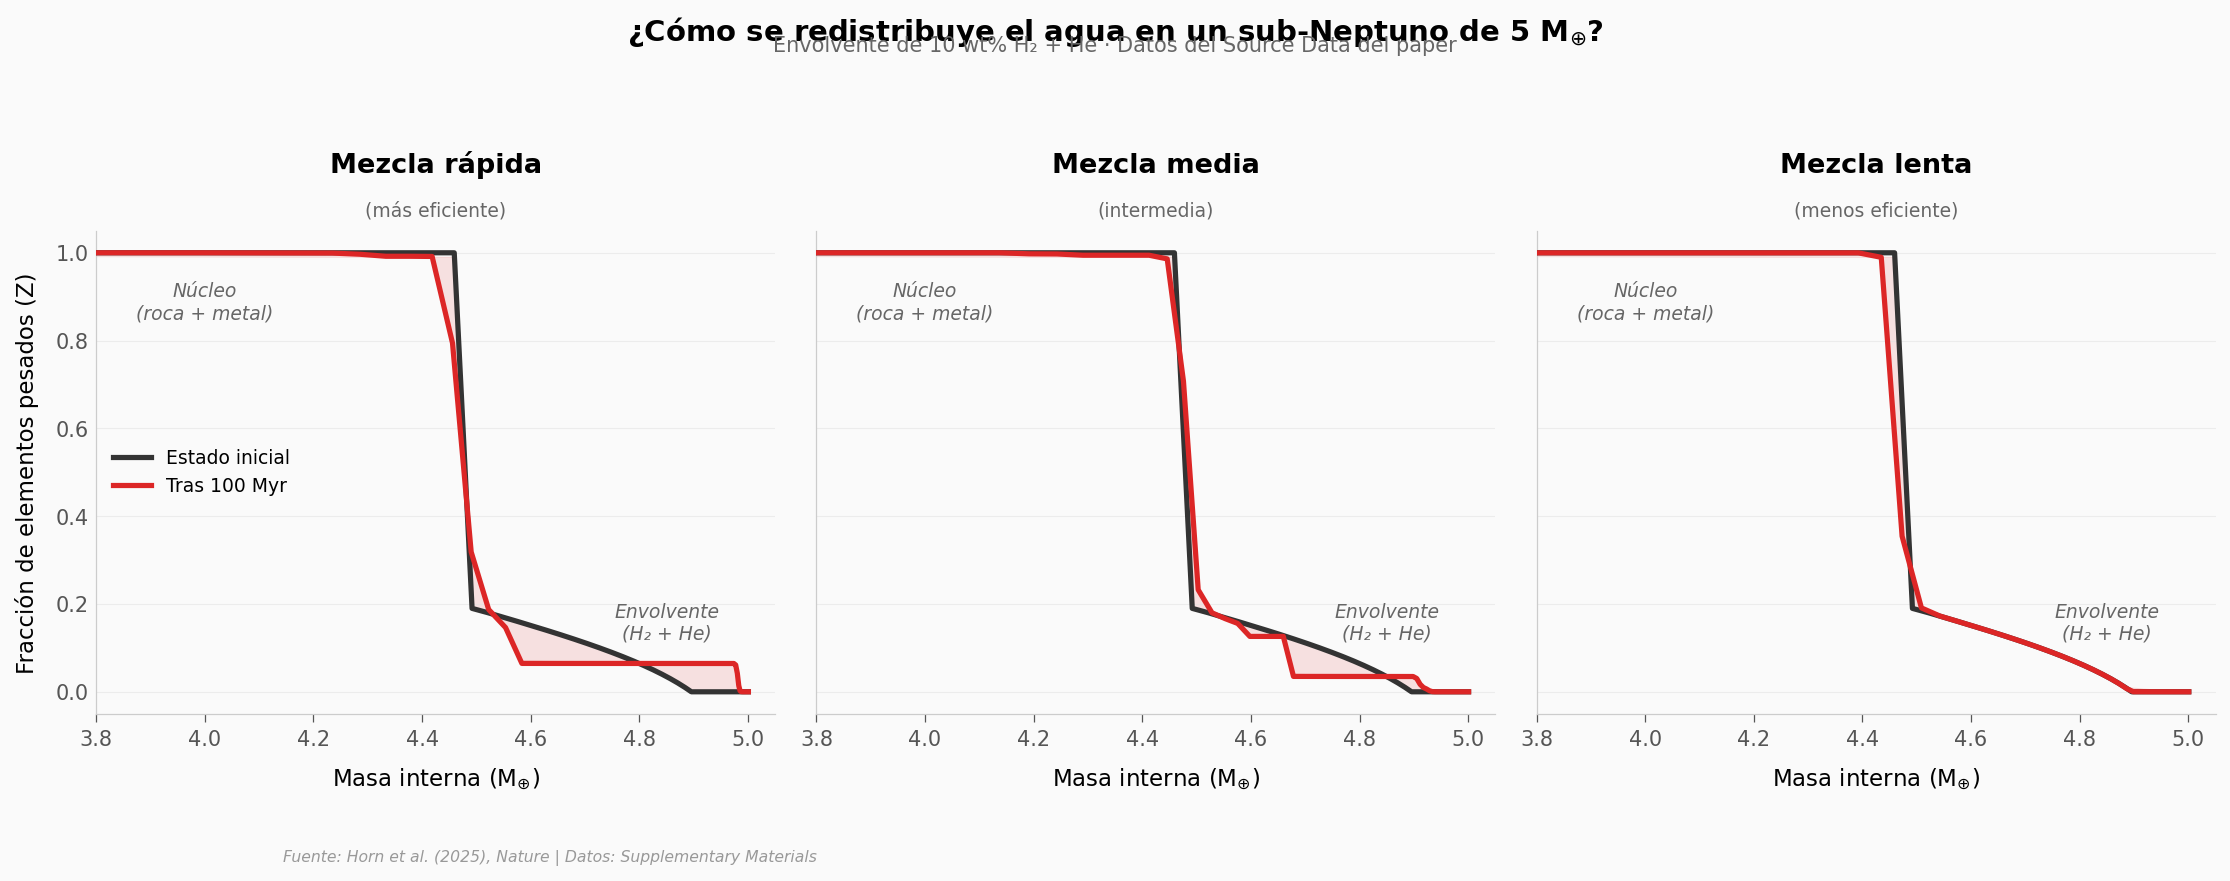

In [2]:
# ── Hero: Evolución de la fracción de elementos pesados (Z) ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

escenarios = [
    ('a', 'Mezcla rápida', '(más eficiente)'),
    ('b', 'Mezcla media', '(intermedia)'),
    ('c', 'Mezcla lenta', '(menos eficiente)')
]

for ax, (letter, title, subtitle) in zip(axes, escenarios):
    # Estado inicial (curva negra)
    ax.plot(df_evol[f'masa_inicial_{letter}'],
            df_evol[f'z_inicial_{letter}'],
            color='#333333', linewidth=2.5, label='Estado inicial',
            zorder=5)
    
    # Estado después de 100 Myr (curva roja)
    ax.plot(df_evol[f'masa_100myr_{letter}'],
            df_evol[f'z_100myr_{letter}'],
            color=COLOR_ALERTA, linewidth=2.5, label='Tras 100 Myr',
            zorder=5)
    
    # Sombrear zona de mezcla
    z100 = df_evol[f'z_100myr_{letter}']
    m100 = df_evol[f'masa_100myr_{letter}']
    zi = df_evol[f'z_inicial_{letter}']
    mi = df_evol[f'masa_inicial_{letter}']
    ax.fill_betweenx(np.linspace(0, 1, 100),
                      np.interp(np.linspace(0, 1, 100), zi[::-1].values, mi[::-1].values),
                      np.interp(np.linspace(0, 1, 100), z100[::-1].values, m100[::-1].values),
                      alpha=0.12, color=COLOR_ALERTA)
    
    ax.set_xlabel('Masa interna (M$_⊕$)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, subtitle, transform=ax.transAxes,
            fontsize=9, color='#666666', ha='center')
    ax.set_xlim(3.8, 5.05)
    ax.set_ylim(-0.05, 1.05)
    
    # Anotar regiones
    ax.text(4.0, 0.85, 'Núcleo\n(roca + metal)',
            fontsize=9, color='#666666', ha='center', style='italic')
    ax.text(4.85, 0.12, 'Envolvente\n(H₂ + He)',
            fontsize=9, color='#666666', ha='center', style='italic')

axes[0].set_ylabel('Fracción de elementos pesados (Z)', fontsize=11)
axes[0].legend(fontsize=9, loc='center left', framealpha=0.9)

fig.suptitle('¿Cómo se redistribuye el agua en un sub-Neptuno de 5 M$_⊕$?',
             fontsize=14, fontweight='bold', y=1.07)
fig.text(0.5, 1.02, f'Envolvente de {ENVOLVENTE_WT_PCT} wt% H₂ + He · Datos del Source Data del paper',
         fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/evolucion_planetaria.png', dpi=200, bbox_inches='tight')
plt.show()

### ¿Qué vemos?

La curva negra es el estado inicial: el núcleo rocoso (Z = 1, todo elementos pesados) y la envolvente gaseosa (Z ≈ 0, casi todo hidrógeno y helio) están separados por un borde abrupto. Es como agua y aceite en un vaso.

Después de 100 millones de años (curva roja), la frontera se difumina. La reacción entre el hidrógeno y el magma del núcleo produce agua y la mezcla convectiva la distribuye por la envolvente. La zona sombreada es donde ocurre la acción: el agua "contagia" la envolvente.

Lo interesante: la eficiencia de mezcla importa. Si el planeta mezcla rápido (panel izquierdo), el agua se reparte de forma más uniforme. Si mezcla lento (panel derecho), la capa profunda de la envolvente termina mucho más rica en agua que la superficial — un gradiente que podría detectarse con telescopios como el JWST.

## La receta: magma + hidrógeno = agua

En el laboratorio, la reacción se ve así: el olivino (el mineral más abundante del manto rocoso), junto con hierro metálico, se mezcla con hidrógeno a 8 GPa. El silicio del olivino se reduce, forma una aleación Fe-Si, y el oxígeno liberado se combina con hidrógeno para producir agua.

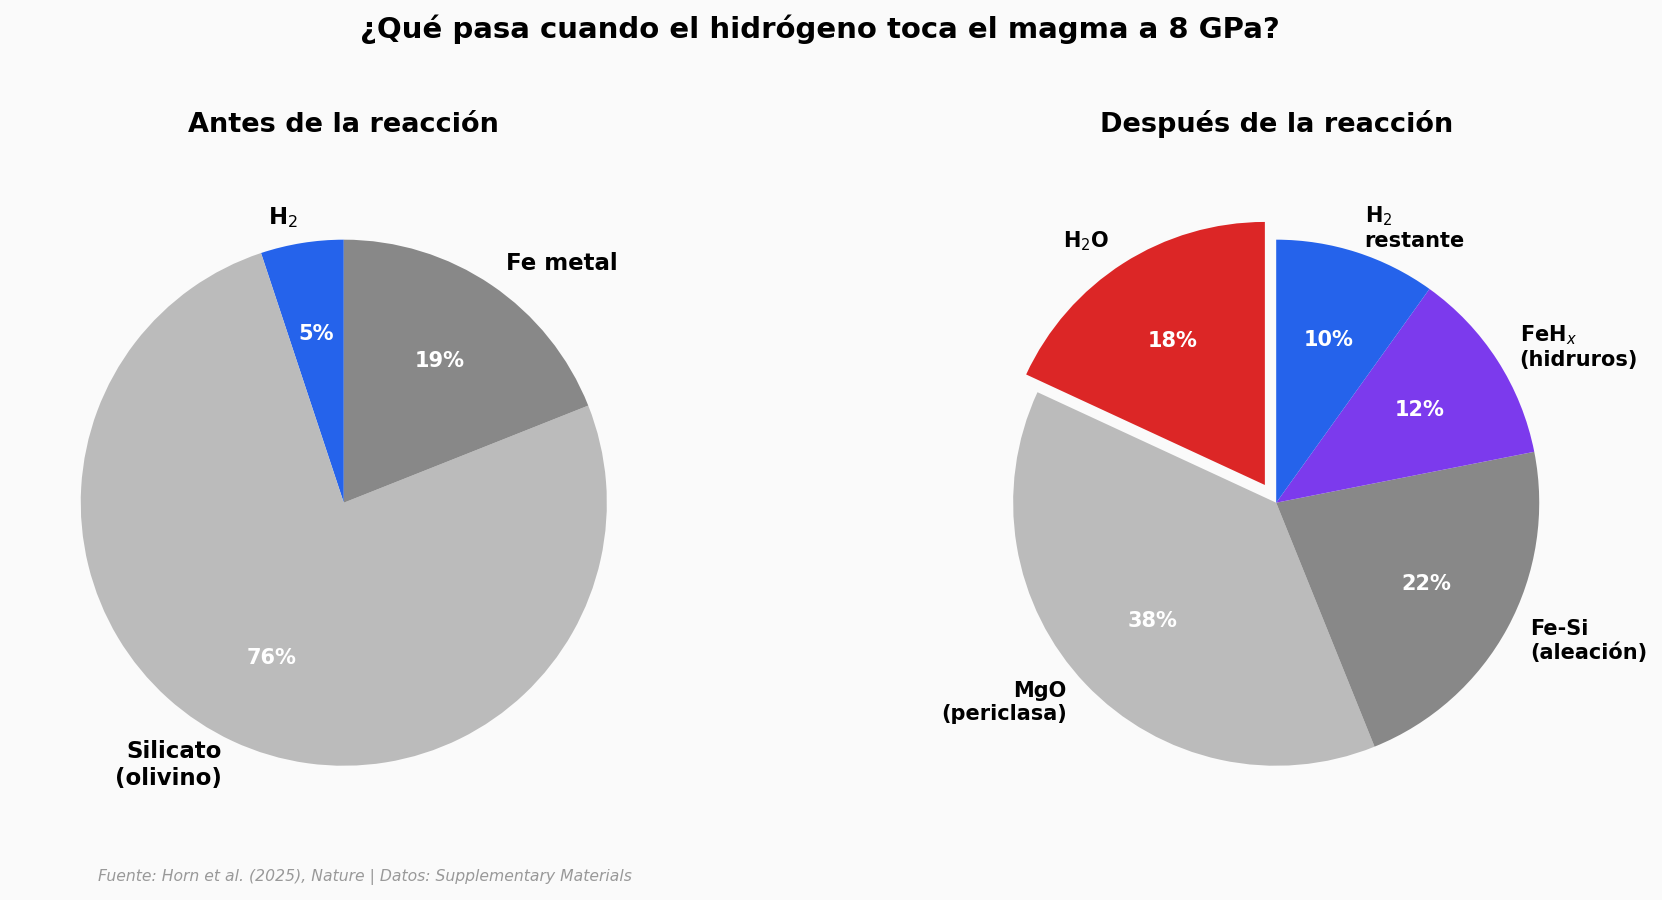

In [3]:
# ── Balance de masa: antes y después de la reacción ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Antes de la reacción
antes = {'H$_2$': 5.1, 'Silicato\n(olivino)': 76, 'Fe metal': 19}
colores_antes = [COLOR_DATOS, COLOR_GRIS, '#888888']

wedges_a, texts_a, autotexts_a = axes[0].pie(
    antes.values(), labels=antes.keys(), colors=colores_antes,
    autopct='%1.0f%%', startangle=90, pctdistance=0.65,
    textprops={'fontsize': 11, 'fontweight': 'bold'})
for at in autotexts_a:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')
axes[0].set_title('Antes de la reacción', fontsize=13, fontweight='bold', pad=20)

# Después de la reacción (basado en cálculos del paper)
# Total 100 wt%: 18.1% H₂O + MgO + FeSi + FeH + H₂ residual
# Paper: la mezcla experimental produjo ~18.1 wt% H₂O
# El resto: MgO periclasa, aleación Fe-Si, hidruros FeHx, H₂ restante
despues = {'H$_2$O': 18.1, 'MgO\n(periclasa)': 38, 'Fe-Si\n(aleación)': 22,
           'FeH$_x$\n(hidruros)': 12, 'H$_2$\nrestante': 9.9}
colores_despues = [COLOR_ALERTA, COLOR_GRIS, '#888888', COLOR_VIOLETA, COLOR_DATOS]

wedges_d, texts_d, autotexts_d = axes[1].pie(
    despues.values(), labels=despues.keys(), colors=colores_despues,
    autopct='%1.0f%%', startangle=90, pctdistance=0.65,
    explode=(0.08, 0, 0, 0, 0),
    textprops={'fontsize': 10, 'fontweight': 'bold'})
for at in autotexts_d:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')
axes[1].set_title('Después de la reacción', fontsize=13, fontweight='bold', pad=20)

fig.suptitle('¿Qué pasa cuando el hidrógeno toca el magma a 8 GPa?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/balance_reaccion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánta agua puede fabricar un sub-Neptuno real?

En el laboratorio la mezcla era rica en hidrógeno. En un planeta real, solo el 5% exterior del núcleo está en contacto con la envolvente gaseosa. Aun así, la cantidad de agua que se produce depende de la composición del manto: más silicio → más agua.

La comparación con las predicciones anteriores habla sola: ~1.800 veces más agua.

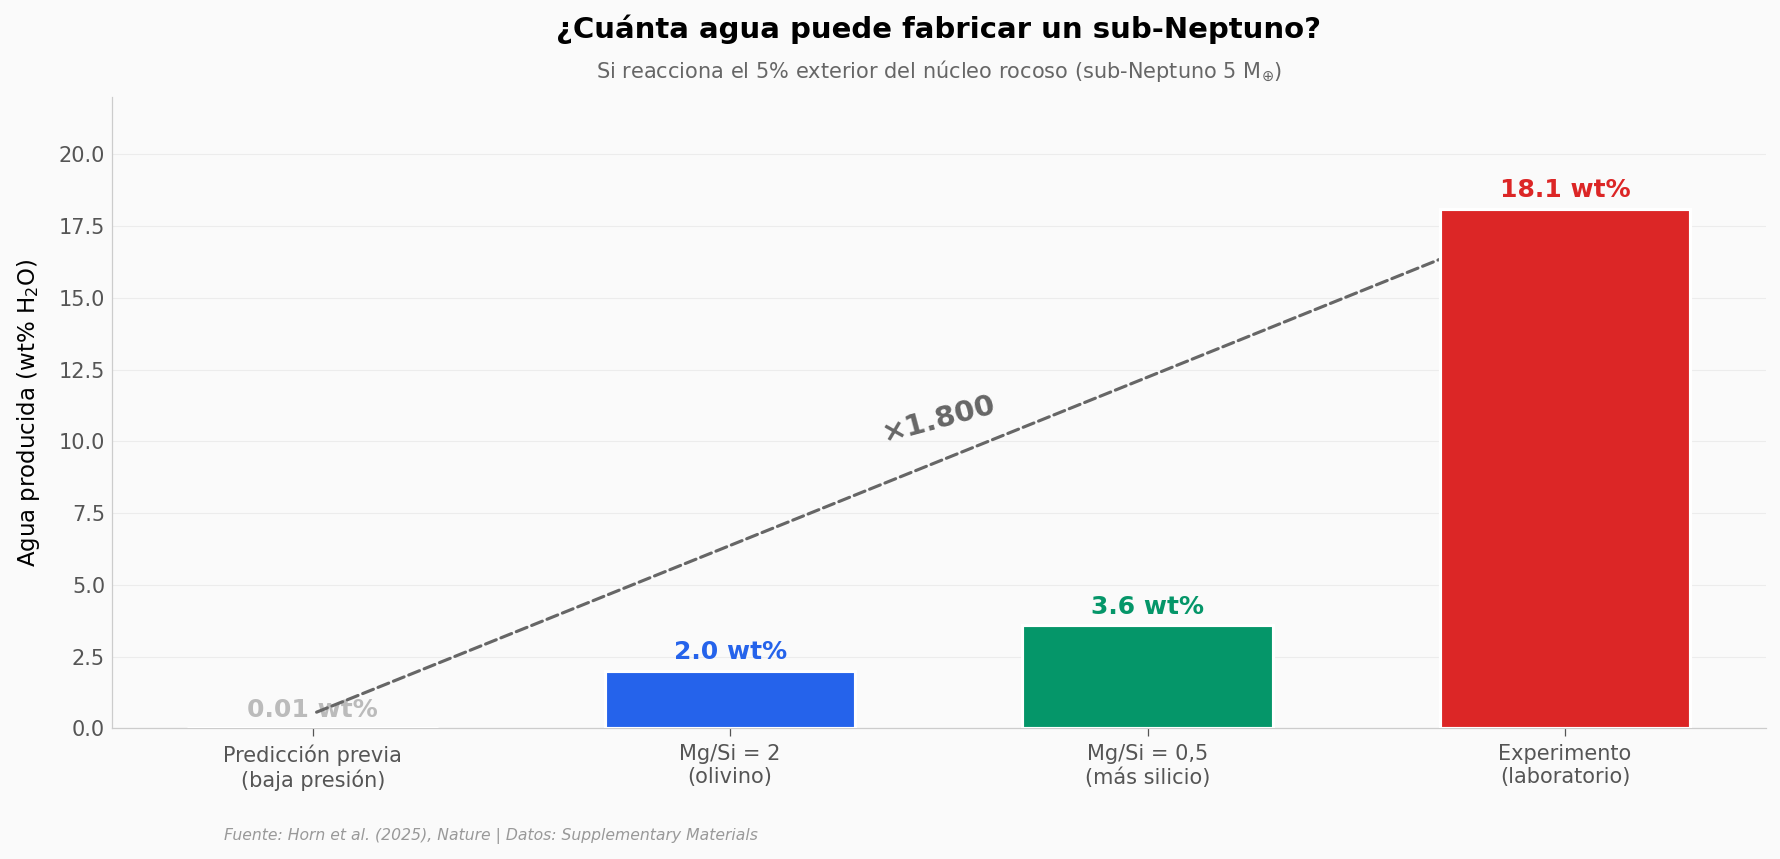

In [4]:
# ── Agua producida vs predicciones previas ──
fig, ax = plt.subplots(figsize=(12, 5.5))

# Datos para la comparación
categorias = [
    'Predicción previa\n(baja presión)',
    'Mg/Si = 2\n(olivino)',
    'Mg/Si = 0,5\n(más silicio)',
    'Experimento\n(laboratorio)'
]
valores = [H2O_PREDICCION_PREVIA, 2.0, 3.6, H2O_EXPERIMENTAL]
colores = [COLOR_GRIS, COLOR_DATOS, COLOR_SECUNDARIO, COLOR_ALERTA]

bars = ax.bar(categorias, valores, color=colores, width=0.6,
              edgecolor='white', linewidth=1.5, zorder=5)

# Etiquetas de valor
for bar, val in zip(bars, valores):
    label = f'{val} wt%' if val >= 1 else f'{val} wt%'
    y_pos = bar.get_height() + 0.4
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label,
            ha='center', fontsize=12, fontweight='bold',
            color=bar.get_facecolor())

# Anotar la diferencia
ax.annotate('', xy=(3, H2O_EXPERIMENTAL), xytext=(0, H2O_PREDICCION_PREVIA + 0.5),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.5, ls='--'))
ax.text(1.5, 10, '×1.800', fontsize=14, fontweight='bold', color='#666666',
        ha='center', rotation=15)

ax.set_ylabel('Agua producida (wt% H$_2$O)', fontsize=11)
ax.set_title('¿Cuánta agua puede fabricar un sub-Neptuno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Si reacciona el 5% exterior del núcleo rocoso (sub-Neptuno 5 M$_⊕$)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 22)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/agua_vs_predicciones.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan lejos estaban los modelos previos?

Los modelos anteriores, basados en datos a presiones bajas, predecían que las reacciones hidrógeno-silicato apenas producirían 0,01 wt% de agua (10⁻² wt%). A las presiones reales de un sub-Neptuno (8–42 GPa), la reacción produce 18,1 wt% — unas **1.800 veces más**.

¿Dónde cae ese 18,1% en el contexto de los sub-Neptunos conocidos?

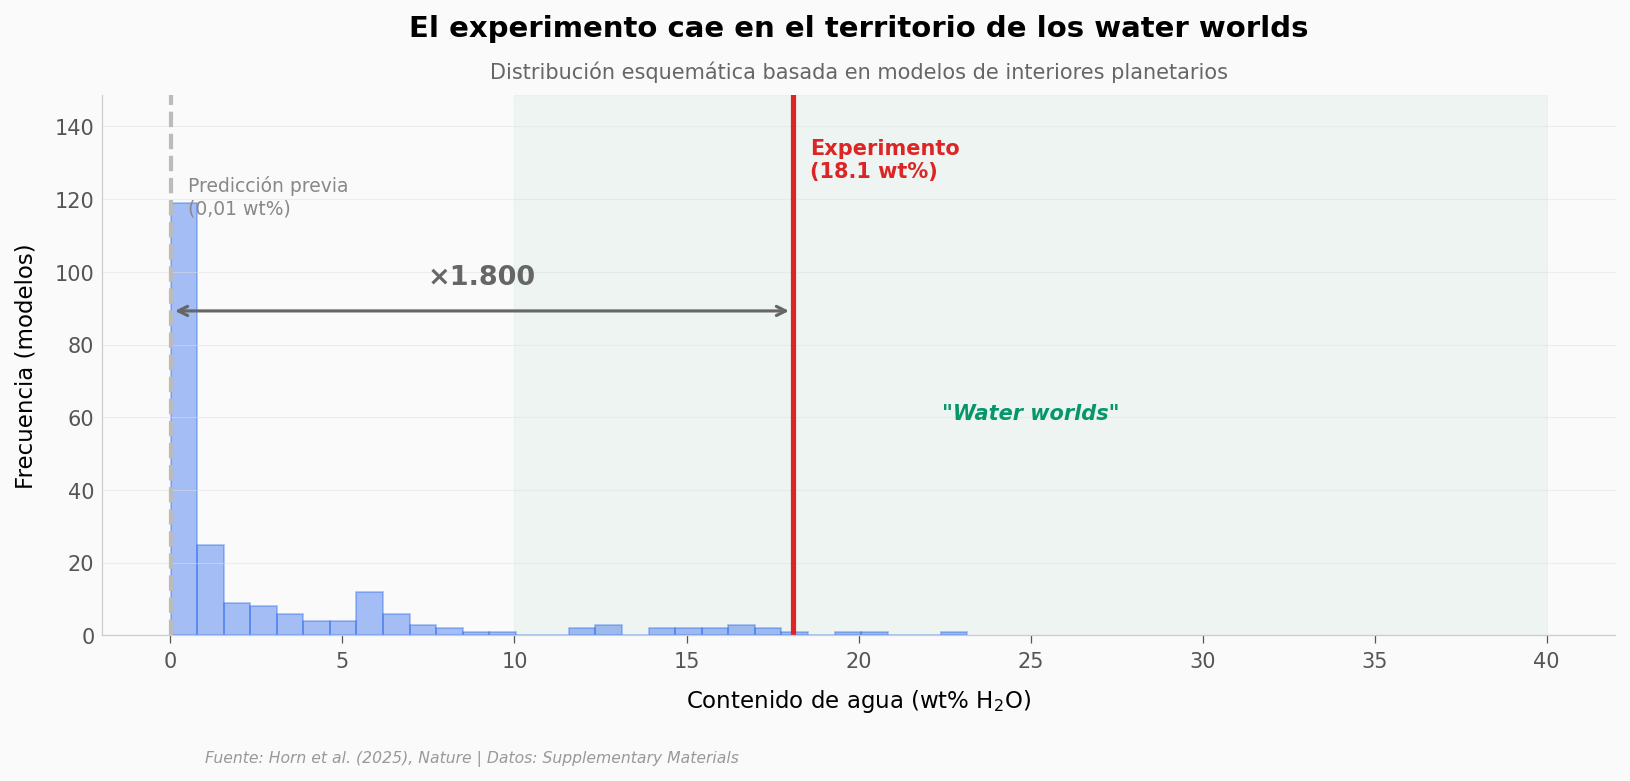

In [5]:
# ── Histograma: 18,1 wt% en contexto ──
fig, ax = plt.subplots(figsize=(11, 5))

# Rango de contenido de agua modelado para sub-Neptunos (literatura)
# Basado en los modelos de interiores: desde planetas secos (H₂) hasta water worlds
np.random.seed(42)
# Distribución típica de modelos de agua en sub-Neptunos
modelos_agua = np.concatenate([
    np.random.exponential(0.5, 150),     # Mayoría con poco agua
    np.random.normal(5, 2, 50),          # Algunos intermedios
    np.random.normal(15, 3, 20),         # Pocos water-worlds
])
modelos_agua = modelos_agua[(modelos_agua > 0) & (modelos_agua < 40)]

n, bins, patches = ax.hist(modelos_agua, bins=30, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)

y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea de predicción previa
ax.axvline(x=H2O_PREDICCION_PREVIA, color=COLOR_GRIS, linewidth=2, linestyle='--')
ax.text(H2O_PREDICCION_PREVIA + 0.5, y_max * 0.85, 'Predicción previa\n(0,01 wt%)',
        fontsize=9, color='#888888', va='top')

# Línea del experimento
ax.axvline(x=H2O_EXPERIMENTAL, color=COLOR_ALERTA, linewidth=2.5)
ax.text(H2O_EXPERIMENTAL + 0.5, y_max * 0.92, f'Experimento\n({H2O_EXPERIMENTAL} wt%)',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, va='top')

# Flecha bidireccional
ax.annotate('', xy=(H2O_EXPERIMENTAL, y_max * 0.6),
            xytext=(H2O_PREDICCION_PREVIA, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((H2O_EXPERIMENTAL + H2O_PREDICCION_PREVIA) / 2, y_max * 0.65,
        '×1.800', fontsize=13, fontweight='bold', color='#666666', ha='center')

# Zona de "water worlds"
ax.axvspan(10, 40, alpha=0.05, color=COLOR_SECUNDARIO, zorder=0)
ax.text(25, y_max * 0.4, '"Water worlds"', fontsize=10,
        color=COLOR_SECUNDARIO, ha='center', style='italic', fontweight='bold')

ax.set_xlabel('Contenido de agua (wt% H$_2$O)', fontsize=11)
ax.set_ylabel('Frecuencia (modelos)', fontsize=11)
ax.set_title('El experimento cae en el territorio de los water worlds',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución esquemática basada en modelos de interiores planetarios',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/histograma_agua.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La reacción H₂ + silicato produce 18,1 wt% de agua a 8 GPa | ✅ | Dato experimental directo. 18,1 ± 0,5 wt% medido en la celda de diamante |
| Los modelos previos subestimaban la producción de agua en ~1.800× | ✅ | 18,1 wt% vs 10⁻² wt% predicho por extrapolaciones de baja presión |
| Un sub-Neptuno de 5 M⊕ puede producir 2–4 wt% de agua con solo el 5% del núcleo | ✅ | Cálculo del Supplementary Code 2. 2,0 wt% para Mg/Si=2, 3,6 wt% para Mg/Si=0,5 |
| El agua se redistribuye por la envolvente vía mezcla convectiva | ⚠️ | Soportado por el modelo de evolución (Source Data, Fig. 3), pero la eficiencia de mezcla es un parámetro libre |
| Detectar agua en la atmósfera no implica que el planeta migró | ⚠️ | Conclusión lógica del paper. Los datos experimentales la soportan, pero la extrapolación a planetas reales depende de modelos |

> **Limitaciones:** (1) El experimento usó olivino de San Carlos + Fe como análogo del manto, no composiciones reales de sub-Neptunos. (2) Solo se redujo el 32% del Si (y=0,27); el máximo teórico (86%) requeriría consumir todo el Fe. (3) La eficiencia de mezcla convectiva en el modelo es un parámetro ajustable. (4) Los datos de evolución planetaria (Fig. 3) son de un modelo, no de observaciones directas.

## Ahora tú

1. **¿Qué pasa si el planeta es más grande?** Cambia `MASA_PLANETA_ME` a 10 o 15. ¿Cómo cambia la zona de mezcla en la celda de la hero chart? (Pista: la masa del núcleo escala, pero la proporción que reacciona también.)

2. **¿Cuánta agua necesita un sub-Neptuno para ser un "water world"?** Los modelos consideran >10 wt% como water world. Con la eficiencia observada (32% de conversión de Si), ¿qué fracción del núcleo tendría que reaccionar? (Pista: el 5% exterior produce 2–4 wt%.)

3. **¿Y si cambiamos la composición del manto?** La celda experimental usa Mg/Si = 2 (olivino). Si usas el valor para Mg/Si = 0,5 en `H2O_EXPERIMENTAL`, ¿cómo cambia el histograma? ¿Se acerca más al territorio de water worlds?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué fracción del núcleo necesita reaccionar para llegar a 10 wt% H₂O?

# Datos del paper
h2o_por_5pct_nucleo = 3.0  # wt% H₂O promedio (entre 2.0 y 4.0)
objetivo_h2o = 10.0        # wt% H₂O para "water world"

fraccion_nucleo_necesaria = (objetivo_h2o / h2o_por_5pct_nucleo) * 5
print(f"Para alcanzar {objetivo_h2o} wt% H₂O:")
print(f"  Necesitamos que reaccione el {fraccion_nucleo_necesaria:.0f}% del núcleo")
print(f"  (asumiendo la misma eficiencia que el 5% exterior)")
print()

# ¿Es realista? El paper dice que el núcleo se mantiene fundido
# por miles de millones de años gracias a la envolvente aislante
print("¿Es realista?")
print(f"  El 5% exterior es la zona en contacto directo con H₂")
print(f"  El {fraccion_nucleo_necesaria:.0f}% requiere que la reacción penetre más profundo")
print(f"  El paper sugiere que esto es posible si la convección")
print(f"  del magma expone continuamente roca fresca al hidrógeno")

Para alcanzar 10.0 wt% H₂O:
  Necesitamos que reaccione el 17% del núcleo
  (asumiendo la misma eficiencia que el 5% exterior)

¿Es realista?
  El 5% exterior es la zona en contacto directo con H₂
  El 17% requiere que la reacción penetre más profundo
  El paper sugiere que esto es posible si la convección
  del magma expone continuamente roca fresca al hidrógeno


---

### Créditos

- **Paper:** Horn, H. W., Vazan, A., Chariton, S. et al. *Building wet planets through high-pressure magma–hydrogen reactions*. Nature (2025). DOI: [10.1038/s41586-025-09630-7](https://doi.org/10.1038/s41586-025-09630-7)
- **Datos:** Source Data (MOESM4) y Supplementary Code del paper. Los datos experimentales originales están en [Zenodo](https://doi.org/10.5281/zenodo.15586691) (acceso restringido).
- **Licencia datos:** Según los términos de [Springer Nature](https://www.nature.com/nature/editorial-policies).
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)